# Day 2 EDA, Preprocessing, and Smoke-Test Notes

This notebook documents the Day 2 artifacts used before encoder training. Day 2 focuses on inspecting prepared data, tokenizing it into a HuggingFace `DatasetDict`, validating label alignment, and confirming the encoder pipeline with a small smoke test.


## Related Day 2 Files

| File | Role |
|---|---|
| `scripts/02_preprocess.py` | Tokenizes injected parquet splits and writes the HuggingFace dataset. |
| `scripts/02_smoke_test.py` | Runs a small DistilBERT smoke test to validate Trainer, metrics, and dataset wiring. |
| `src/pii_masking/day2_preprocessing.py` | Reusable tokenization and Strategy B BIO label-alignment logic. |
| `src/pii_masking/day2_metrics.py` | Reusable seqeval and token-level metric helpers for encoder checks. |
| `data/processed/hf_dataset/` | Tokenized HuggingFace `DatasetDict` consumed by the Kaggle encoder notebook. |
| `models/smoke_test_distilbert/smoke_test_results.json` | Saved local smoke-test metrics. |
| `reports/figures/day2_token_length_distribution.png` | Token-length EDA figure generated during Day 1 validation and reused here to justify `max_length=256`. |


## How To Reproduce Day 2

Run from the project root after Day 1 artifacts exist:

```bash
python scripts/02_preprocess.py
python scripts/02_smoke_test.py
```

Day 2 consumes `data/processed/train_with_emails.parquet`, `data/processed/val_with_emails.parquet`, and `data/processed/test_injected.parquet` from Day 1.


## Display Token-Length Histogram

Purpose: show the saved token-length figure used to justify the preprocessing cutoff. Critical thinking: validate that `max_length=256` covers the sentence lengths before tokenizing for encoder training.


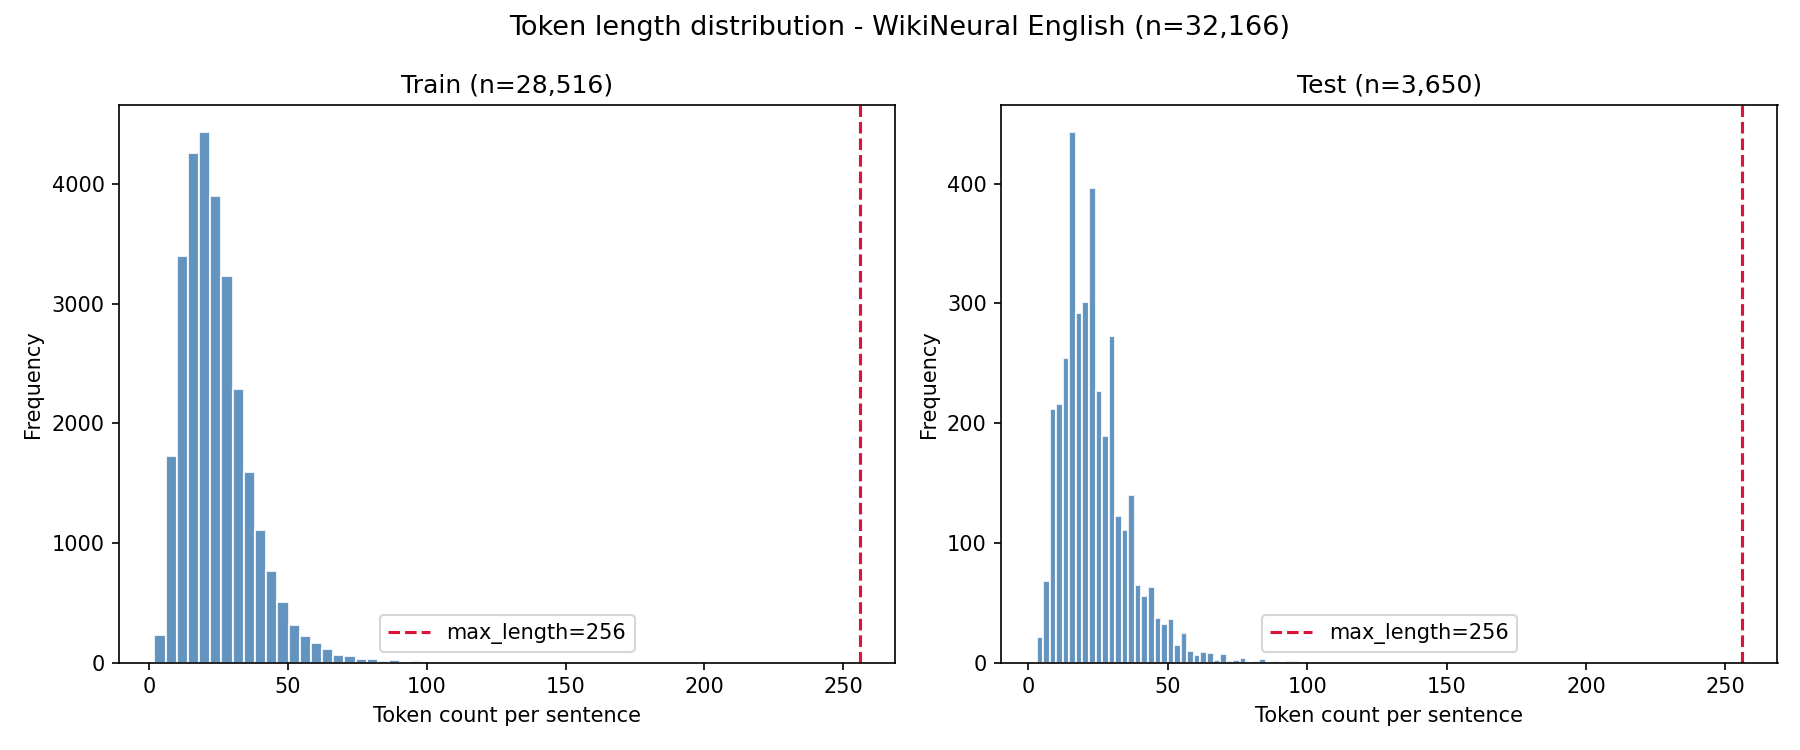

In [1]:
from pathlib import Path
from IPython.display import Image, display

hist_path = Path('../reports/figures/day2_token_length_distribution.png')
if hist_path.exists():
    display(Image(filename=str(hist_path)))
else:
    print(f'Histogram not found at {hist_path}. Run scripts/01_validate_data.py first.')


## Inspect HuggingFace Dataset Metadata

Purpose: confirm that Day 2 preprocessing produced the expected `DatasetDict` structure. Critical thinking: verify split availability and dataset files before using them for Kaggle encoder training.


In [2]:
import json
from pathlib import Path

hf_path = Path('../data/processed/hf_dataset')
dataset_dict_path = hf_path / 'dataset_dict.json'
if dataset_dict_path.exists():
    dataset_meta = json.loads(dataset_dict_path.read_text(encoding='utf-8'))
    print('HF dataset path:', hf_path)
    print(json.dumps(dataset_meta, indent=2))
    for split in ['train', 'validation', 'test']:
        split_path = hf_path / split
        print(f'{split}:', 'exists' if split_path.exists() else 'missing')
else:
    print(f'HuggingFace dataset metadata not found at {dataset_dict_path}. Run scripts/02_preprocess.py first.')


HF dataset path: ..\data\processed\hf_dataset
{
  "splits": [
    "train",
    "validation",
    "test"
  ]
}
train: exists
validation: exists
test: exists


## Summarize Smoke-Test Results

Purpose: load the saved Day 2 smoke-test JSON. Critical thinking: check that the local small-run encoder pipeline produced reasonable metrics before relying on full Kaggle training.


In [3]:
import json
from pathlib import Path

smoke_path = Path('../models/smoke_test_distilbert/smoke_test_results.json')
if smoke_path.exists():
    smoke = json.loads(smoke_path.read_text(encoding='utf-8'))
    metrics = smoke.get('eval_metrics', {})
    print('Smoke test artifact:', smoke_path)
    print('Model:', smoke.get('model'))
    print('Epochs:', smoke.get('epochs'))
    print('Train subset:', smoke.get('train_subset'))
    print('Validation subset:', smoke.get('val_subset'))
    print('Smoke sequence length:', smoke.get('smoke_seq_len'))
    print('Train loss:', smoke.get('train_loss'))
    print('Validation precision:', metrics.get('eval_overall_precision'))
    print('Validation recall:', metrics.get('eval_overall_recall'))
    print('Validation F1:', metrics.get('eval_overall_f1'))
    print('PER F1:', metrics.get('eval_per_f1'))
    print('EMAIL F1:', metrics.get('eval_email_f1'))
    print('Note:', smoke.get('note'))
else:
    print(f'Smoke test results not found at {smoke_path}. Run scripts/02_smoke_test.py if needed.')


Smoke test artifact: ..\models\smoke_test_distilbert\smoke_test_results.json
Model: distilbert-base-cased
Epochs: 1
Train subset: 2500
Validation subset: 500
Smoke sequence length: 64
Train loss: 0.03375
Validation precision: 0.9347
Validation recall: 0.9611
Validation F1: 0.9477
PER F1: 0.9346
EMAIL F1: 0.9813
Note: CPU smoke test with 2500-example subset and 64-token truncation. Full 24k dataset + 256 tokens for Day 3 GPU run.


## Notes For Evaluators

- This notebook documents and inspects Day 2 outputs; it does not replace the scripts.
- `scripts/02_preprocess.py` is the source of truth for tokenization and label alignment.
- `scripts/02_smoke_test.py` is the source of truth for the local encoder pipeline smoke test.
- Full encoder training happens later in `notebooks/03_encoder_training.ipynb` on Kaggle/GPU.
